In [1]:
# Core Python
import os
import re
import string
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Visualization for NLP
from wordcloud import WordCloud


In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Check if GPU is available
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Optional: set memory growth to avoid allocation issues
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("CUDA GPU activated and memory growth set.")
    except RuntimeError as e:
        print(e)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled for faster training.")



Num GPUs Available: 0
Mixed precision enabled for faster training.


In [3]:
df = pd.read_csv('data/main/Amazon_reviews_2023.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   rating             701528 non-null  int64 
 1   title              701368 non-null  object
 2   text               701316 non-null  object
 3   images             701528 non-null  object
 4   asin               701528 non-null  object
 5   parent_asin        701528 non-null  object
 6   user_id            701528 non-null  object
 7   timestamp          701528 non-null  object
 8   helpful_vote       701528 non-null  int64 
 9   verified_purchase  701528 non-null  bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 48.8+ MB


In [5]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [6]:
df.isna().sum()

rating                 0
title                160
text                 212
images                 0
asin                   0
parent_asin            0
user_id                0
timestamp              0
helpful_vote           0
verified_purchase      0
dtype: int64

In [7]:
df[df["title"].isna() & df["text"].isna()].head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
9078,5,NaN,NaN,[],B07RV86B18,B07RV86B18,AGWG6V5GXDLTR3ULS6LX2WV672CQ,2019-11-10 00:38:55.104,0,True
29389,4,NaN,NaN,[],B079D6VTX2,B079D6VTX2,AE3SRD3YFD2U32HGTOOJVU7LDRCA,2020-07-19 13:21:56.050,0,True
34286,3,NaN,NaN,[],B08GYD2LDY,B08GYD2LDY,AH7VW63QYWWNE6RUZ34SEO2HQ6LA,2022-10-25 22:32:02.457,0,True
34289,3,NaN,NaN,[],B09C18HXXJ,B09C18HXXJ,AH7VW63QYWWNE6RUZ34SEO2HQ6LA,2022-10-25 22:22:00.242,0,True
54622,4,NaN,NaN,[],B00OQKBNUG,B00OQKBNUG,AFLUDL7AERAAQA64C4KKT5VTD6JA,2021-07-12 18:52:15.895,0,True


In [8]:
# Create review column
df["review"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
).str.strip()

# Remove rows with empty reviews
df = df[df["review"] != ""].copy()

# Drop original columns
df.drop(columns=["title", "text"], inplace=True)

In [9]:
df.isna().sum()

rating               0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
review               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(7275)

In [11]:
df = df.drop_duplicates()

The dataset contained 7,275 exact duplicate records, which were removed to eliminate redundant information. Duplicate review texts across different users or products were intentionally retained because they represent legitimate customer opinions rather than data quality issues.

In [12]:
df.memory_usage(deep=True)

Index                  5553560
rating                 5553560
images                73116864
asin                  46511065
parent_asin           46511065
user_id               59008279
timestamp             55535600
helpful_vote           5553560
verified_purchase       694195
review               241375744
dtype: int64

In [13]:
df.nunique()


rating                    5
images                58938
asin                 115706
parent_asin          112563
user_id              631941
timestamp            693969
helpful_vote            240
verified_purchase         2
review               671598
dtype: int64

In [14]:
df["timestamp"].head()

0    2020-05-05 14:08:48.923
1    2020-05-04 18:10:55.070
2    2020-05-16 21:41:06.052
3    2022-01-28 18:13:50.220
4    2020-12-30 10:02:43.534
Name: timestamp, dtype: object

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [16]:
def sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["rating"].apply(sentiment_label)

df["char_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

df["sentence_count"] = (df["review"].str.count(r"[.!?]").clip(lower=1))

In [17]:
print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1]}")

Dataset Shape: (694195, 13)
Number of Features: 13


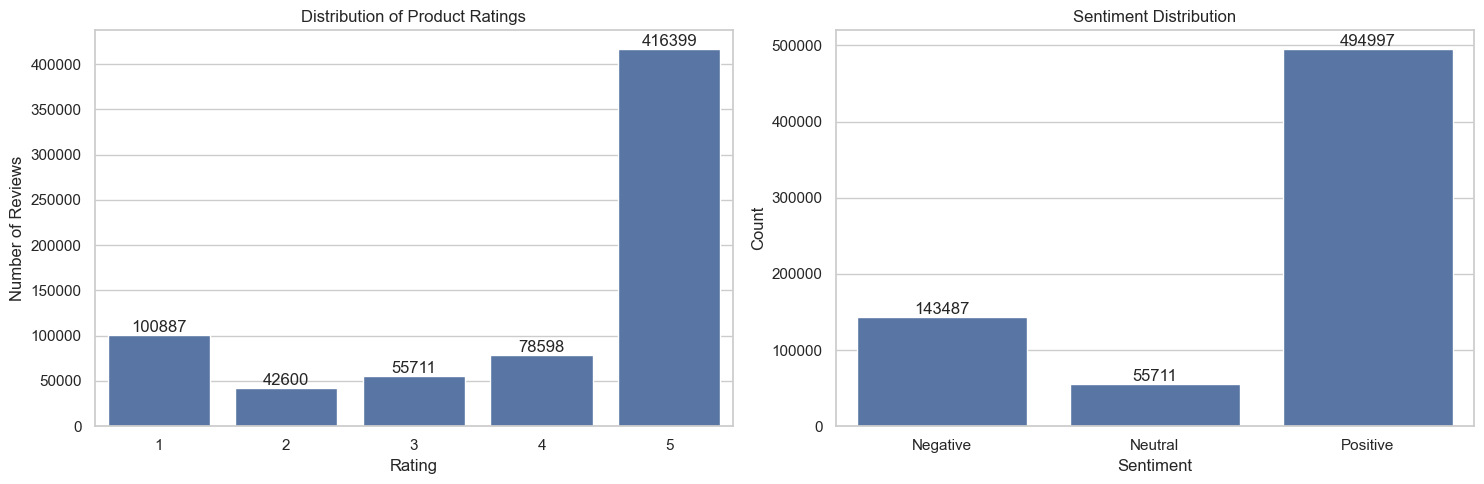

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15,5)) 

# First subplot: Ratings
ax1 = sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].unique()),
    ax=axes[0]
)
ax1.set_title("Distribution of Product Ratings")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Number of Reviews")

for container in ax1.containers:
    ax1.bar_label(container)

# Second subplot: Sentiment
ax2 = sns.countplot(
    data=df,
    x="sentiment",
    order=["Negative","Neutral","Positive"],
    ax=axes[1]
)
ax2.set_title("Sentiment Distribution")
ax2.set_xlabel("Sentiment")
ax2.set_ylabel("Count")

for container in ax2.containers:
    ax2.bar_label(container)

plt.tight_layout()
plt.show()


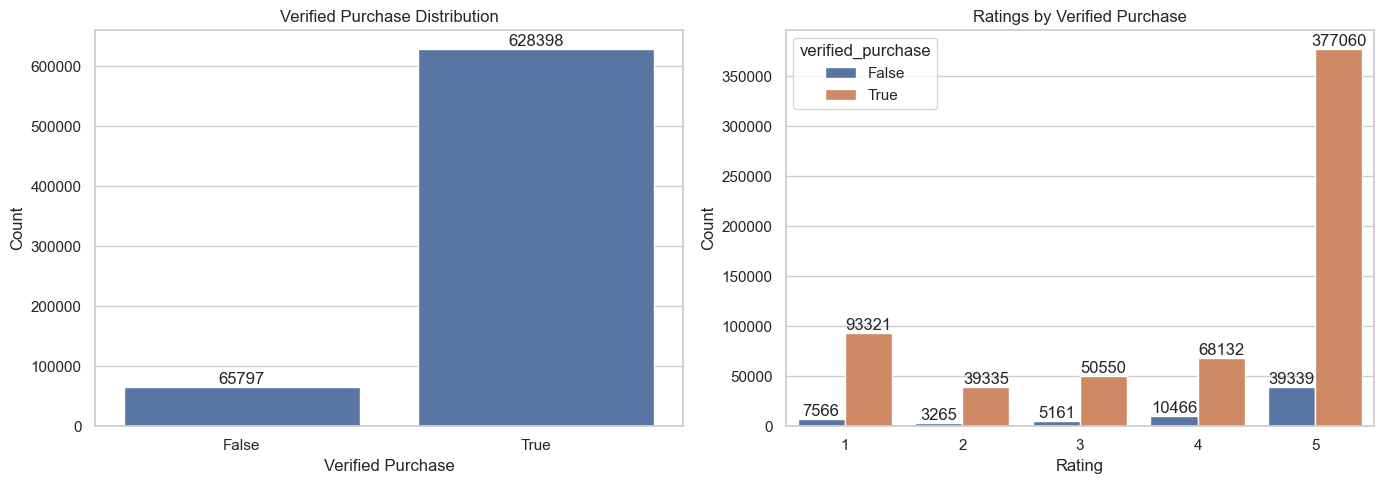

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns

# First subplot: Verified Purchase count
ax1 = sns.countplot(
    data=df,
    x="verified_purchase",
    ax=axes[0]
)
ax1.set_title("Verified Purchase Distribution")
ax1.set_xlabel("Verified Purchase")
ax1.set_ylabel("Count")

for container in ax1.containers:
    ax1.bar_label(container)

# Second subplot: Rating by Verified Purchase
ax2 = sns.countplot(
    data=df,
    x="rating",
    hue="verified_purchase",
    ax=axes[1]
)
ax2.set_title("Ratings by Verified Purchase")
ax2.set_xlabel("Rating")
ax2.set_ylabel("Count")

for container in ax2.containers:
    ax2.bar_label(container)

plt.tight_layout()
plt.show()


In [20]:
df["helpful_vote"].describe()

count    694195.000000
mean          0.924243
std           5.487522
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         646.000000
Name: helpful_vote, dtype: float64

<Axes: xlabel='word_count', ylabel='Count'>

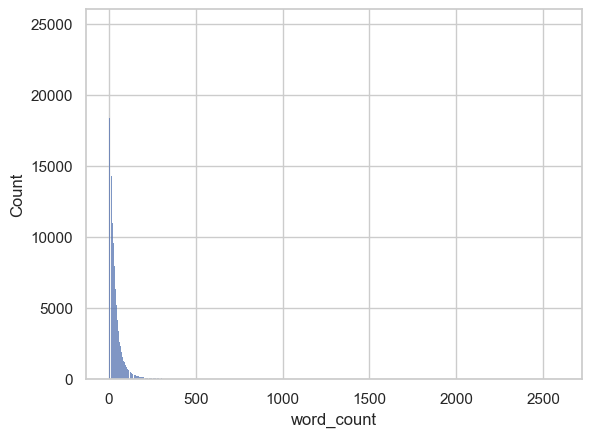

In [21]:
sns.histplot(df["word_count"])

In [22]:
len(df.word_count.unique())

812

<Axes: xlabel='rating', ylabel='word_count'>

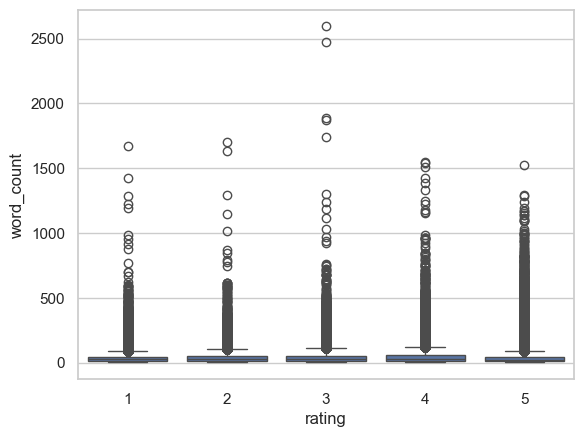

In [23]:
sns.boxplot(
    data=df,
    x="rating",
    y="word_count"
)

In [24]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month

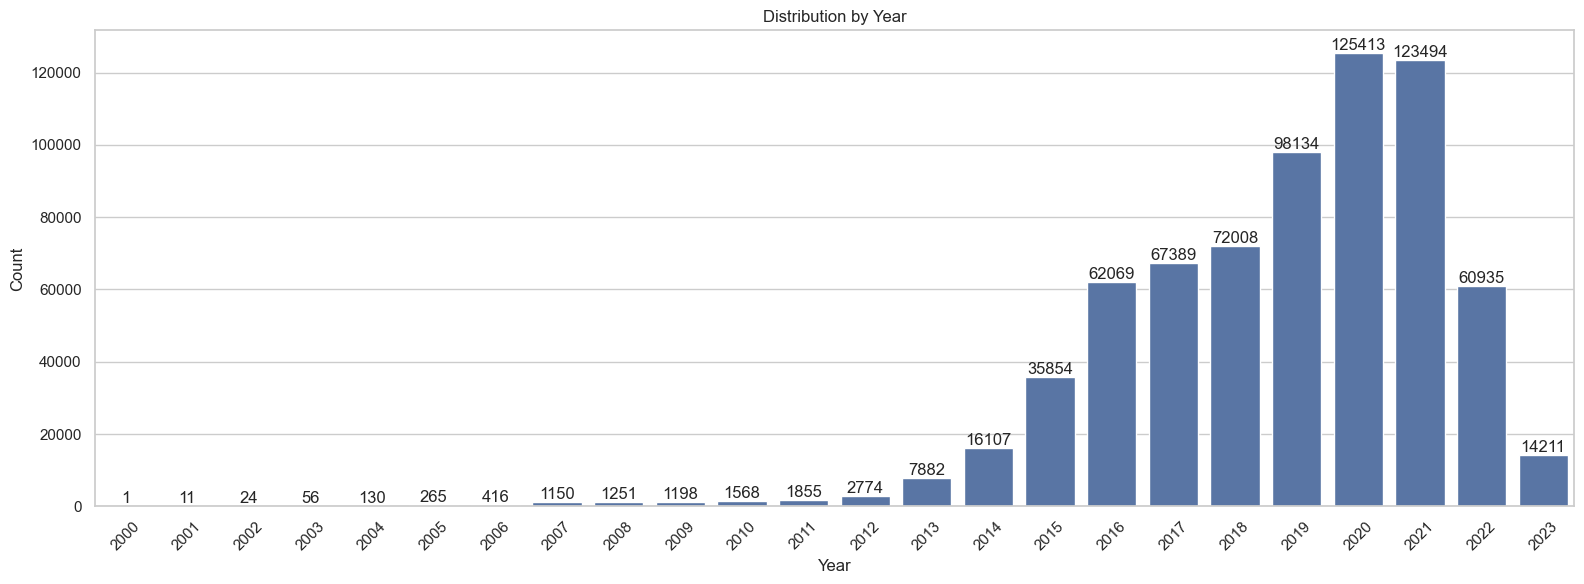

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,6))  # wider figure

ax = sns.countplot(
    data=df,
    x="year"
)

plt.title("Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


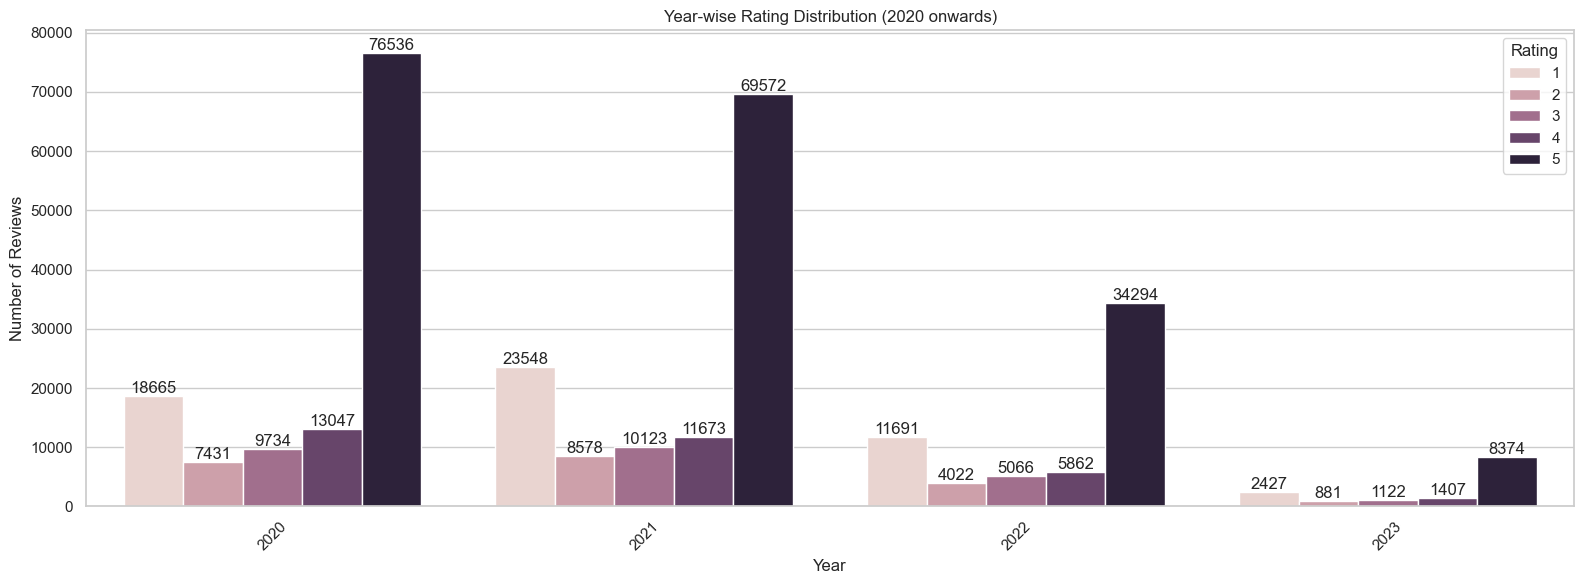

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only years >= 2020
df_filtered = df[df["year"] >= 2020]

plt.figure(figsize=(16,6))

ax = sns.countplot(
    data=df_filtered,
    x="year",
    hue="rating",
    order=sorted(df_filtered["year"].unique()),
    hue_order=[1,2,3,4,5]
)

plt.title("Year-wise Rating Distribution (2020 onwards)")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.legend(title="Rating")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [27]:
# Count reviews per product (asin) and get the one with max reviews
most_reviewed = df['asin'].value_counts().idxmax()
review_count = df['asin'].value_counts().max()
highest_avg_rating = df.groupby('asin')['rating'].mean().idxmax()
avg_rating_value = df.groupby('asin')['rating'].mean().max()


print("Most reviewed product:", most_reviewed, "with", review_count, "reviews")
print("Highest average rating product:", highest_avg_rating, "with average rating", avg_rating_value)


Most reviewed product: B007IAE5WY with 1951 reviews
Highest average rating product: 0005946468 with average rating 5.0


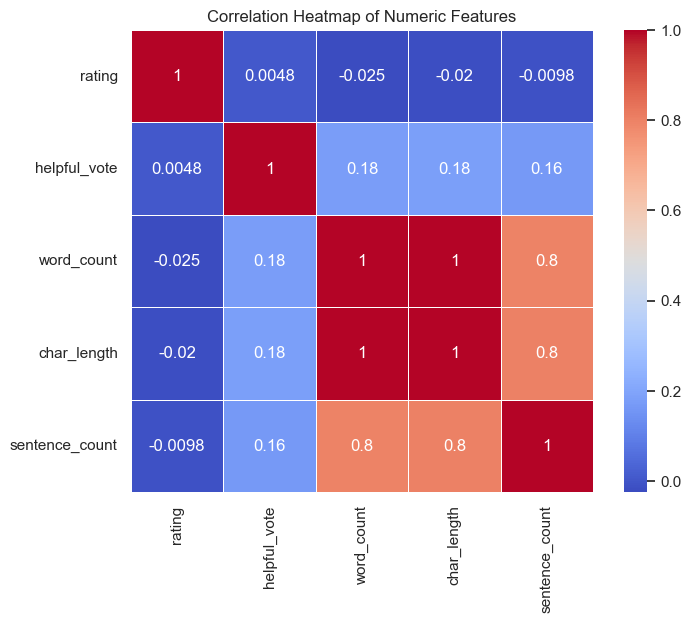

In [28]:
num_cols = [
    "rating",
    "helpful_vote",
    "word_count",
    "char_length",
    "sentence_count"
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()


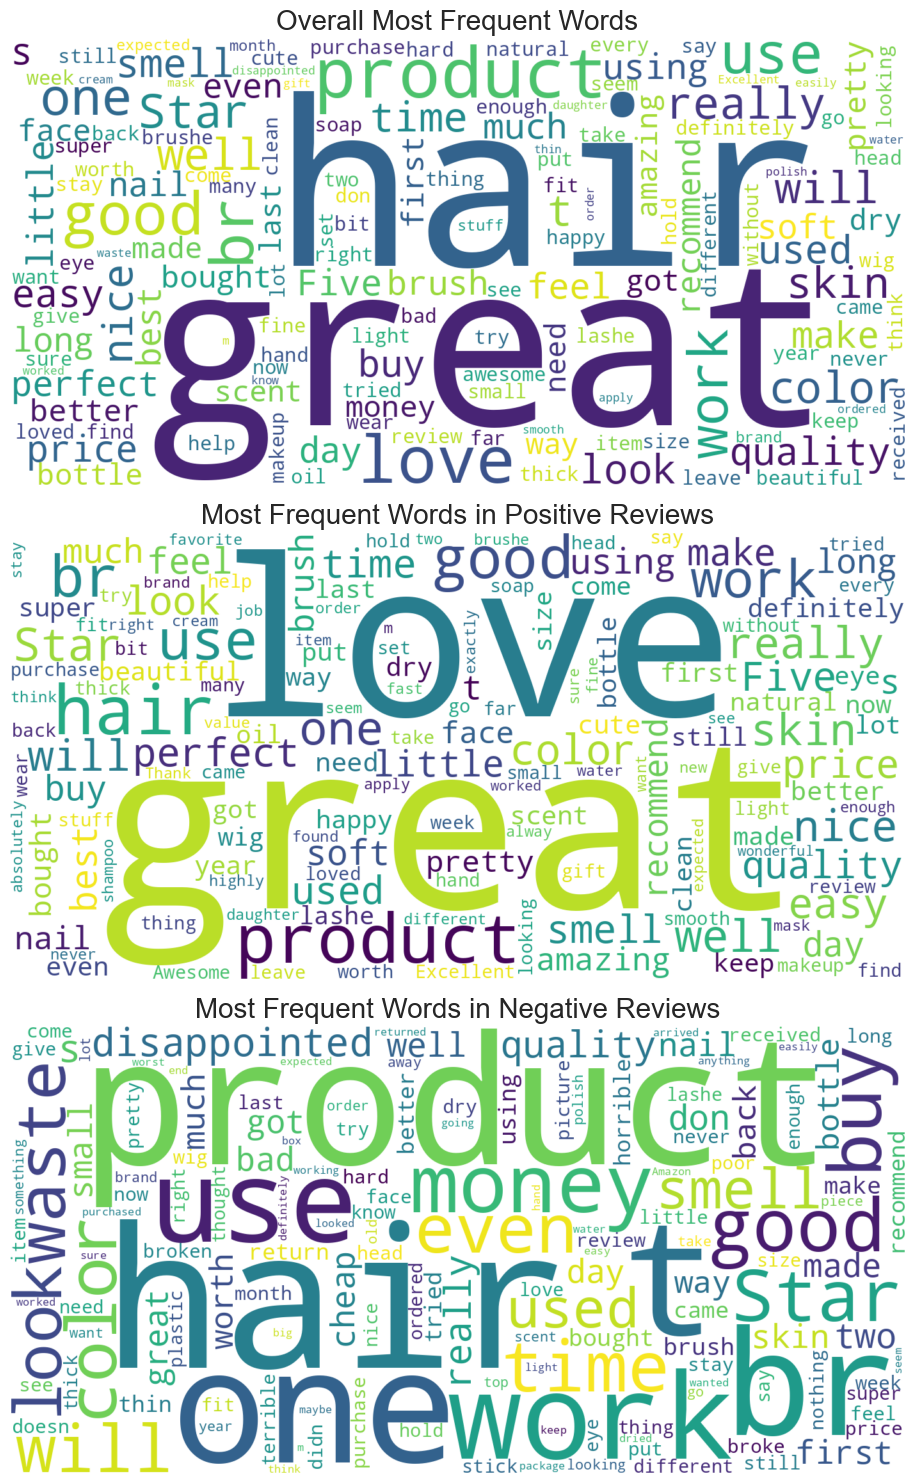

In [30]:
text_col = "review"
df[text_col] = df[text_col].fillna("").astype(str)

df["sentiment"] = df["rating"].apply(
    lambda x: "Negative" if x <= 2 else "Neutral" if x == 3 else "Positive"
)

# Word clouds
all_text = " ".join(df[text_col])
positive_text = " ".join(df.loc[df["sentiment"] == "Positive", text_col])
negative_text = " ".join(df.loc[df["sentiment"] == "Negative", text_col])

wordcloud_all = WordCloud(width=1400, height=700, background_color="white",
                          max_words=150, collocations=False).generate(all_text)

wordcloud_positive = WordCloud(width=1400, height=700, background_color="white",
                               max_words=150, collocations=False).generate(positive_text)

wordcloud_negative = WordCloud(width=1400, height=700, background_color="white",
                               max_words=150, collocations=False).generate(negative_text)

# Display
plt.figure(figsize=(18, 15))

plt.subplot(3, 1, 1)
plt.imshow(wordcloud_all, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Most Frequent Words", fontsize=20)

plt.subplot(3, 1, 2)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Positive Reviews", fontsize=20)

plt.subplot(3, 1, 3)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Negative Reviews", fontsize=20)

plt.tight_layout()
plt.show()


# 📊 Exploratory Data Analysis (EDA) Summary

The exploratory data analysis provided valuable insights into the structure, quality, and characteristics of the Amazon Reviews dataset before beginning the NLP preprocessing and modeling stages.

## Key Findings

- The dataset is large and well-structured, containing over **700,000 customer reviews**, making it suitable for training both traditional machine learning and deep learning models.

- The **5-star rating** is the most frequent class, while **2-star and 3-star ratings** occur much less often. Consequently, the derived sentiment labels are heavily skewed toward the **Positive** class, indicating a clear **class imbalance** that should be considered during model evaluation.

- The majority of reviews originate from **verified purchases**, suggesting that a large proportion of customer feedback is likely to represent genuine purchasing experiences. Non-verified reviews were retained, as the dataset alone does not provide evidence that they are fraudulent or fake.

- The distribution of **helpful votes** is highly right-skewed. Most reviews received no helpful votes, whereas only a small number of reviews accumulated a large number of helpful votes. These observations represent natural user behavior rather than erroneous outliers.

- Review length (word count and character count) is also highly right-skewed, with most reviews being relatively short while a small number contain detailed customer experiences. Such long reviews were preserved because they may provide valuable contextual information for NLP models.

- Analysis of review length across rating categories revealed no substantial difference, suggesting that customers across different satisfaction levels generally write reviews of comparable length.

- Time-based analysis showed that the number of reviews increased steadily until around **2020**, followed by a decline in later years. Since the dataset may not contain complete records for every year, these temporal trends should be interpreted with caution.

- Product-level analysis identified the most frequently reviewed products as well as products with the highest average ratings, providing useful business insights into customer engagement and product performance.

- Correlation analysis revealed an almost perfect positive correlation between **character length** and **word count**, indicating that both features carry nearly identical information. This redundancy should be considered during feature selection for traditional machine learning models.

## Modeling Implications

The exploratory analysis highlights several important considerations for the modeling phase:

- Address class imbalance using appropriate evaluation metrics such as **Macro F1-score**, **Weighted F1-score**, and the **Confusion Matrix**, rather than relying solely on accuracy.
- Preserve long reviews because they often contain rich contextual information useful for sentiment prediction.
- Consider removing redundant engineered features (e.g., character count or word count) for classical machine learning models.
- Leverage the large dataset to compare multiple approaches, including **Bag of Words**, **TF-IDF**, **Word Embeddings**, **Deep Learning (LSTM/BiLSTM)**, and **Transformer-based models (BERT/DistilBERT)**.

## Conclusion

Overall, the dataset is clean, information-rich, and well suited for natural language processing tasks. The EDA phase established a strong understanding of the data, identified potential modeling challenges such as class imbalance and feature redundancy, and provided valuable business insights that will guide the preprocessing, feature engineering, and model development stages of this project.

# Save Processed Dataset

After completing data understanding, cleaning, feature creation, and exploratory data analysis, the processed dataset is saved for use in the subsequent stages of the project.

Saving the dataset ensures that each notebook remains independent and reproducible, eliminating the need to repeat previous preprocessing steps whenever the project is revisited.

The next notebook focuses on **Text Exploration, NLP Preprocessing, and Feature Engineering**, where the review text will be analyzed in detail before preparing it for machine learning and deep learning models.

In [33]:
df.to_parquet("data/processed/reviews_after_eda.parquet", index=False)